In [ ]:
import numpy as np
# import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text

iris=load_iris()
X=iris.data
y=iris.target

In [7]:
tree_clf=DecisionTreeClassifier(max_depth=7, random_state=42,criterion='gini')
tree_clf.fit(X,y)

tree_rules=export_text(tree_clf,feature_names=iris['feature_names'])
print("--- Decision Tree Internal Flowchart Rules ---")
print(tree_rules)

# 4. Extract and Inspect Feature Importance Variables
print("\n--- Feature Importance Variables Learned ---")
for name, importance in zip(iris.feature_names, tree_clf.feature_importances_):
    print(f"{name:<18}: {importance * 100:.1f}%")

--- Decision Tree Internal Flowchart Rules ---
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2


--- Feature Importance Variables Learned ---
sepal leng

--- Regression Tree Decision Paths ---
|--- Feature_X <= -0.36
|   |--- Feature_X <= -0.43
|   |   |--- Feature_X <= -0.46
|   |   |   |--- Feature_X <= -0.48
|   |   |   |   |--- Feature_X <= -0.49
|   |   |   |   |   |--- value: [0.76]
|   |   |   |   |--- Feature_X >  -0.49
|   |   |   |   |   |--- value: [0.74]
|   |   |   |--- Feature_X >  -0.48
|   |   |   |   |--- Feature_X <= -0.47
|   |   |   |   |   |--- value: [0.69]
|   |   |   |   |--- Feature_X >  -0.47
|   |   |   |   |   |--- value: [0.71]
|   |   |--- Feature_X >  -0.46
|   |   |   |--- Feature_X <= -0.45
|   |   |   |   |--- value: [0.57]
|   |   |   |--- Feature_X >  -0.45
|   |   |   |   |--- Feature_X <= -0.44
|   |   |   |   |   |--- Feature_X <= -0.45
|   |   |   |   |   |   |--- value: [0.64]
|   |   |   |   |   |--- Feature_X >  -0.45
|   |   |   |   |   |   |--- value: [0.66]
|   |   |   |   |--- Feature_X >  -0.44
|   |   |   |   |   |--- Feature_X <= -0.44
|   |   |   |   |   |   |--- value: [0.60]
|   |   |

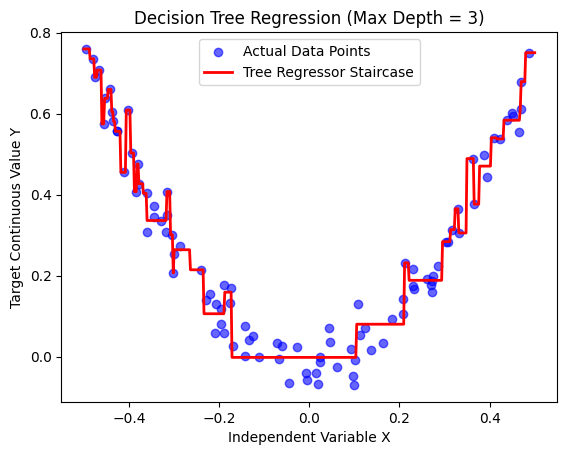

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text


np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X**2 + np.random.randn(100, 1) * 0.05

tree_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_reg.fit(X, y)

tree_rules = export_text(tree_reg, feature_names=["Feature_X"])
print("--- Regression Tree Decision Paths ---")
print(tree_rules)

X_grid = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred = tree_reg.predict(X_grid)

plt.scatter(X, y, color="blue", alpha=0.6, label="Actual Data Points")
plt.plot(X_grid, y_pred, color="red", linewidth=2, label="Tree Regressor Staircase")
plt.xlabel("Independent Variable X")
plt.ylabel("Target Continuous Value Y")
plt.title("Decision Tree Regression (Max Depth = 3)")
plt.legend()
plt.show()